# TLC taxi Trips (Yellow + Green + FHVHV)

The primary crowd-demand signal for Zentra.
TLC taxi + ride hail pickups per zone per 15 mins becomes the crowd_score it will be used as a training target ahead and also the dominant input feature for the decided algorithm

## Datasets
1. NYC TLC Yellow Taxi Trip Records (Parquet)
2. NYC TLC Green Taxi Trip Records (Parquet)
3. NYC TLC For-Hire Vehicle High Volume (FHVHV-Uber,etc) Trip Records (Parquet)

All data processing will have manhattan zones filter in it 

I'm trying to all the data from all dataset from jan 2024 to feb 2024

In [2]:
# imports 
from pathlib import Path
import requests, pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm


# pandas configuations 
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 40)

# seaborn plot theme 
sns.set_theme(style='whitegrid', font_scale=1.05)

# will try to separate raw and processed data 
RAW = Path('../data/tlc/raw'); RAW.mkdir(parents=True, exist_ok=True)
PROC = Path('../data/tlc/processed'); PROC.mkdir(parents=True, exist_ok=True)


# Manhattan taxi zones (TLC zone IDs within Manhattan borough)
# Source: TLC Txi Zone Lookup - Borough = Manhattan 
# https://data.cityofnewyork.us/Transportation/NYC-Taxi-Zones/d3c5-ddgc

MANHATTAN_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100,
    103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140, 141, 142,
    143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194,
    202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243,
    244, 246, 249, 261, 262, 263
}

print(f'Manhattan zones: {len(MANHATTAN_ZONES)}')

Manhattan zones: 69


c:\Users\shaya\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Downloading the data from the source
# All data from Jan-Feb 2024.
# Yellow, Green and FHVHV
# Direct URL links for the datasets
URLS = {
    'yellow_2024_01': 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet',
    'yellow_2024_02': 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet',
    'green_2024_01':  'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2024-01.parquet',
    'green_2024_02':  'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2024-02.parquet',
    'fhvhv_2024_01':  'https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2024-01.parquet',
    'fhvhv_2024_02':  'https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2024-02.parquet',
}


# A function to download all this data
#  https://requests.readthedocs.io/en/latest/user/advanced/#body-content-workflow
#  https://requests.readthedocs.io/en/latest/user/quickstart
#  https://tqdm.github.io/
def download(url: str, dest: Path) -> Path:
    if dest.exists():
        print(f'Already downloaded: {dest.name}')
        return dest
    print(f'Downloading {dest.name}')
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        total = int(r.headers.get('Content-Length', 0))
        with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dest.name, leave=False) as bar:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk); bar.update(len(chunk))
    return dest

paths = {}
for key, url in URLS.items():
    dest = RAW / f'{key}.parquet'
    paths[key] = download(url, dest)        

Already downloaded: yellow_2024_01.parquet
Already downloaded: yellow_2024_02.parquet
Already downloaded: green_2024_01.parquet
Already downloaded: green_2024_02.parquet
Already downloaded: fhvhv_2024_01.parquet
Already downloaded: fhvhv_2024_02.parquet


# Load, Filter to Manhattan & Raw Inspection

In [5]:
df = pd.read_parquet(RAW / "yellow_2024_01.parquet")
print(df.columns.tolist())
df.head()

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.000,1.720,1.000,N,186,79,2,17.700,1.000,0.500,0.000,0.000,1.000,22.700,2.500,0.000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.000,1.800,1.000,N,140,236,1,10.000,3.500,0.500,3.750,0.000,1.000,18.750,2.500,0.000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.000,4.700,1.000,N,236,79,1,23.300,3.500,0.500,3.000,0.000,1.000,31.300,2.500,0.000
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.000,1.400,1.000,N,79,211,1,10.000,3.500,0.500,2.000,0.000,1.000,17.000,2.500,0.000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.000,0.800,1.000,N,211,148,1,7.900,3.500,0.500,3.200,0.000,1.000,16.100,2.500,0.000


In [6]:
df = pd.read_parquet(RAW / "green_2024_01.parquet")
print(df.columns.tolist())
df.head()

['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge']


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2024-01-01 00:46:55,2024-01-01 00:58:25,N,1.000,236,239,1.000,1.980,12.800,1.000,0.500,3.610,0.000,NaN,1.000,21.660,1.000,1.000,2.750
1,2,2024-01-01 00:31:42,2024-01-01 00:52:34,N,1.000,65,170,5.000,6.540,30.300,1.000,0.500,7.110,0.000,NaN,1.000,42.660,1.000,1.000,2.750
2,2,2024-01-01 00:30:21,2024-01-01 00:49:23,N,1.000,74,262,1.000,3.080,19.800,1.000,0.500,3.000,0.000,NaN,1.000,28.050,1.000,1.000,2.750
3,1,2024-01-01 00:30:20,2024-01-01 00:42:12,N,1.000,74,116,1.000,2.400,14.200,1.000,1.500,0.000,0.000,NaN,1.000,16.700,2.000,1.000,0.000
4,2,2024-01-01 00:32:38,2024-01-01 00:43:37,N,1.000,74,243,1.000,5.140,22.600,1.000,0.500,6.280,0.000,NaN,1.000,31.380,1.000,1.000,0.000


In [7]:
df = pd.read_parquet(RAW / "fhvhv_2024_01.parquet")
print(df.columns.tolist())
df.head()

['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2024-01-01 00:21:47,2024-01-01 00:25:06,2024-01-01 00:28:08,2024-01-01 01:05:39,161,158,2.830,2251,45.610,0.000,1.250,4.050,2.750,0.000,0.000,40.180,N,N,N,N,N
1,HV0003,B03404,B03404,2024-01-01 00:10:56,2024-01-01 00:11:08,2024-01-01 00:12:53,2024-01-01 00:20:05,137,79,1.570,432,10.050,0.000,0.280,0.890,2.750,0.000,0.000,6.120,N,N,N,N,N
2,HV0003,B03404,B03404,2024-01-01 00:20:04,2024-01-01 00:21:51,2024-01-01 00:23:05,2024-01-01 00:35:16,79,186,1.980,731,18.070,0.000,0.500,1.600,2.750,0.000,0.000,9.470,N,N,N,N,N
3,HV0003,B03404,B03404,2024-01-01 00:35:46,2024-01-01 00:39:59,2024-01-01 00:41:04,2024-01-01 00:56:34,234,148,1.990,930,17.170,0.000,0.470,1.520,2.750,0.000,0.000,11.350,N,N,N,N,N
4,HV0003,B03404,B03404,2024-01-01 00:48:19,2024-01-01 00:56:23,2024-01-01 00:57:21,2024-01-01 01:10:02,148,97,2.650,761,38.670,0.000,1.060,3.430,2.750,0.000,0.000,28.630,N,N,N,N,N


In [8]:
# Each taxi type has different column names, normalise it to a common schema.
# FHVHV records include: hvfhs_license_num (HV0002=Juno, HV0003=Uber, HV0004=Via, HV0005=Lyft)

YELLOW_RENAME = {
    'tpep_pickup_datetime':  'pickup_dt',
    'tpep_dropoff_datetime': 'dropoff_dt',
    'PULocationID':          'zone_id',
    'passenger_count':       'passengers',
    'trip_distance':         'distance_mi',
    'fare_amount':           'fare',
    'tip_amount':            'tip',
    'total_amount':          'total',
    'payment_type':          'payment_type',
    'RatecodeID':            'rate_code',
}
GREEN_RENAME = {
    'lpep_pickup_datetime':  'pickup_dt',
    'lpep_dropoff_datetime': 'dropoff_dt',
    'PULocationID':          'zone_id',
    'passenger_count':       'passengers',
    'trip_distance':         'distance_mi',
    'fare_amount':           'fare',
    'tip_amount':            'tip',
    'total_amount':          'total',
    'payment_type':          'payment_type',
    'RatecodeID':            'rate_code',
}
FHVHV_RENAME = {
    'pickup_datetime':       'pickup_dt',
    'dropoff_datetime':      'dropoff_dt',
    'PULocationID':          'zone_id',
    'trip_miles':            'distance_mi',
    'base_passenger_fare':   'fare',
    'tips':                  'tip',
    'driver_pay':            'driver_pay',
    'hvfhs_license_num':     'hv_license',   
    'shared_request_flag':   'shared_flag',
    'wav_request_flag':      'wav_flag',
}

FHVHV_LICENSE_MAP = {
    'HV0002': 'juno', 'HV0003': 'uber', 'HV0004': 'via', 'HV0005': 'lyft'
}

frames = []
for key, path in paths.items():
    colour = key.split('_')[0]
    schema_names = pq.read_schema(path).names

    if colour in ('yellow', 'green'):
        rename = YELLOW_RENAME if colour == 'yellow' else GREEN_RENAME
        cols = [c for c in rename if c in schema_names]
        df = pd.read_parquet(path, columns=cols).rename(columns=rename)
        df['colour'] = colour
        df['passengers'] = df.get('passengers', pd.Series(dtype=float))

    else:  # fhvhv
        cols = [c for c in FHVHV_RENAME if c in schema_names]
        df = pd.read_parquet(path, columns=cols).rename(columns=FHVHV_RENAME)
        df['colour'] = df['hv_license'].map(FHVHV_LICENSE_MAP).fillna('fhv_other')
        df['passengers'] = 1.0          # FHVHV doesn't record passenger count
        df['total'] = df['fare'].fillna(0) + df['tip'].fillna(0)
        df['payment_type'] = 4          # app-based = card
        df['rate_code'] = np.nan

    # Filter to Manhattan immediately (saves memory)
    df = df[df['zone_id'].isin(MANHATTAN_ZONES)].copy()
    frames.append(df)
    print(f'  {key}: {len(df):,} rows (Manhattan only), {df.shape[1]} cols')

raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal raw rows (Manhattan): {len(raw):,}')
print(f'Columns: {raw.columns.tolist()}')
raw.head(3)

  yellow_2024_01: 2,646,948 rows (Manhattan only), 11 cols
  yellow_2024_02: 2,710,784 rows (Manhattan only), 11 cols
  green_2024_01: 32,847 rows (Manhattan only), 11 cols
  green_2024_02: 31,499 rows (Manhattan only), 11 cols
  fhvhv_2024_01: 7,863,672 rows (Manhattan only), 15 cols
  fhvhv_2024_02: 7,750,155 rows (Manhattan only), 15 cols

Total raw rows (Manhattan): 21,035,905
Columns: ['pickup_dt', 'dropoff_dt', 'zone_id', 'passengers', 'distance_mi', 'fare', 'tip', 'total', 'payment_type', 'rate_code', 'colour', 'driver_pay', 'hv_license', 'shared_flag', 'wav_flag']


,pickup_dt,dropoff_dt,zone_id,passengers,distance_mi,fare,tip,total,payment_type,rate_code,colour,driver_pay,hv_license,shared_flag,wav_flag
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,1.000,1.720,17.700,0.000,22.700,2.000,1.000,yellow,NaN,NaN,NaN,NaN
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,1.000,1.800,10.000,3.750,18.750,1.000,1.000,yellow,NaN,NaN,NaN,NaN
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,1.000,4.700,23.300,3.000,31.300,1.000,1.000,yellow,NaN,NaN,NaN,NaN


In [9]:
print(raw.dtypes.to_string())
for col in raw.columns:
    sample = raw[col].dropna().iloc[:3].tolist()
    print(f'{col:<25} {sample}')    

pickup_dt       datetime64[us]
dropoff_dt      datetime64[us]
zone_id                  int32
passengers             float64
distance_mi            float64
fare                   float64
tip                    float64
total                  float64
payment_type           float64
rate_code              float64
colour                  object
driver_pay             float64
hv_license              object
shared_flag             object
wav_flag                object
pickup_dt                 [Timestamp('2024-01-01 00:57:55'), Timestamp('2024-01-01 00:03:00'), Timestamp('2024-01-01 00:17:06')]
dropoff_dt                [Timestamp('2024-01-01 01:17:43'), Timestamp('2024-01-01 00:09:36'), Timestamp('2024-01-01 00:35:01')]
zone_id                   [186, 140, 236]
passengers                [1.0, 1.0, 1.0]
distance_mi               [1.72, 1.8, 4.7]
fare                      [17.7, 10.0, 23.3]
tip                       [0.0, 3.75, 3.0]
total                     [22.7, 18.75, 31.3]
payment_type    

# Data Quality Plan

In [10]:
# DQP — Completeness, Cardinality, Distribution 
def dqp(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        n_null = s.isna().sum()
        n_valid = s.notna().sum()
        dtype = str(s.dtype)
        row = {
            'column':       col,
            'dtype':        dtype,
            'null_count':   n_null,
            'null_pct':     round(n_null / len(df) * 100, 2),
            'unique':       s.nunique(),
            'top_value':    s.value_counts().index[0] if n_valid > 0 else None,
            'top_freq_pct': round(s.value_counts().iloc[0] / len(df) * 100, 2) if n_valid > 0 else 0,
        }
        if pd.api.types.is_numeric_dtype(s):
            row.update({
                'min':    round(float(s.min()), 3),
                'mean':   round(float(s.mean()), 3),
                'median': round(float(s.median()), 3),
                'max':    round(float(s.max()), 3),
                'std':    round(float(s.std()), 3),
                'zeros':  int((s == 0).sum()),
                'neg':    int((s < 0).sum()),
            })
        rows.append(row)
    return pd.DataFrame(rows).set_index('column')

dqp_raw = dqp(raw)
dqp_raw

,dtype,null_count,null_pct,unique,top_value,top_freq_pct,min,mean,median,max,std,zeros,neg
column,,,,,,,,,,,,,
pickup_dt,datetime64[us],0,0.000,4676354,2024-02-15 07:45:00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dropoff_dt,datetime64[us],0,0.000,4679924,2024-01-15 17:41:25,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone_id,int32,0,0.000,67,161,3.640,4.000,159.364,161.000,263.000,69.537,0.000,0.000
passengers,float64,300317,1.430,10,1.000,93.220,0.000,1.081,1.000,9.000,0.444,"60,282.000",0.000
distance_mi,float64,0,0.000,49423,1.000,0.540,0.000,4.310,2.280,"312,722.300",136.048,"102,055.000",0.000
fare,float64,0,0.000,31192,10.000,1.400,-895.000,23.622,17.830,"9,792.000",20.942,"4,004.000","66,666.000"
tip,float64,0,0.000,6480,0.000,62.710,-140.000,1.774,0.000,543.330,3.489,"13,191,327.000",93.000
total,float64,0,0.000,49722,16.800,0.440,-753.740,26.635,20.630,"9,792.000",22.204,"3,399.000","60,246.000"
payment_type,float64,2345,0.010,6,4.000,74.600,0.000,3.263,4.000,5.000,1.285,"297,972.000",0.000


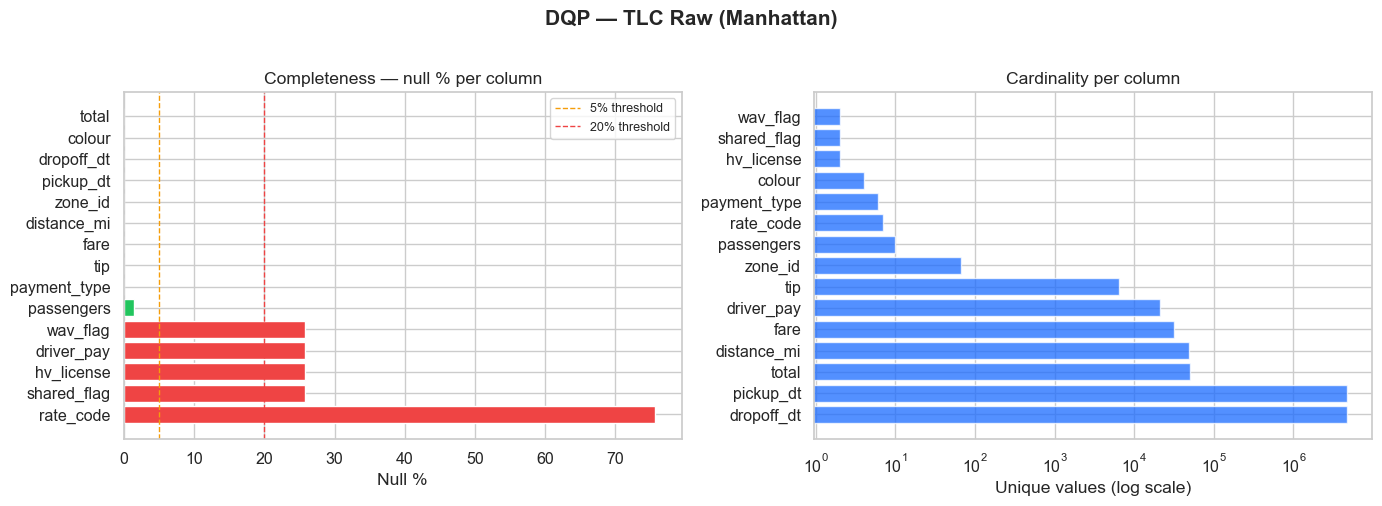

In [11]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


BLUE, ORANGE, RED, GREEN, PURPLE = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6'
null_pct = dqp_raw['null_pct'].sort_values(ascending=False)
colors = [RED if v > 20 else ORANGE if v > 5 else GREEN for v in null_pct.values]
axes[0].barh(null_pct.index, null_pct.values, color=colors)
axes[0].axvline(5,  color=ORANGE, linestyle='--', lw=1, label='5% threshold')
axes[0].axvline(20, color=RED,    linestyle='--', lw=1, label='20% threshold')
axes[0].set_xlabel('Null %')
axes[0].set_title('Completeness — null % per column')
axes[0].legend(fontsize=9)

uni = dqp_raw['unique'].sort_values(ascending=False)
axes[1].barh(uni.index, uni.values, color=BLUE, alpha=0.75)
axes[1].set_xscale('log')
axes[1].set_xlabel('Unique values (log scale)')
axes[1].set_title('Cardinality per column')

plt.suptitle('DQP — TLC Raw (Manhattan)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cleaning

In [12]:
# Parse datetimes
tlc = raw.copy()
tlc['pickup_dt']  = pd.to_datetime(tlc['pickup_dt'],  errors='coerce')
tlc['dropoff_dt'] = pd.to_datetime(tlc['dropoff_dt'], errors='coerce')

# Business rules 
N0 = len(tlc)
reasons = {}

# Manhattan zones (already filtered, but double-check)
mask = tlc['zone_id'].isin(MANHATTAN_ZONES)
reasons['non-Manhattan zone_id'] = (~mask).sum()
tlc = tlc[mask]

# Valid datetime range (Jan–Feb 2024)
mask = (tlc['pickup_dt'] >= '2024-01-01') & (tlc['pickup_dt'] < '2024-03-01')
reasons['datetime out of range'] = (~mask).sum()
tlc = tlc[mask]

# Dropoff after pickup
mask = tlc['dropoff_dt'] > tlc['pickup_dt']
reasons['dropoff <= pickup'] = (~mask).sum()
tlc = tlc[mask]

# Sensible trip duration
tlc['duration_min'] = (tlc['dropoff_dt'] - tlc['pickup_dt']).dt.total_seconds() / 60
mask = tlc['duration_min'].between(0.5, 180)
reasons['duration out of range'] = (~mask).sum()
tlc = tlc[mask]

# Sensible distance
mask = tlc['distance_mi'].fillna(1).between(0, 100)
reasons['distance out of range'] = (~mask).sum()
tlc = tlc[mask]

# Sensible fare (allow $0 for comps, no negatives, cap $600 for FHVHV surge)
mask = tlc['fare'].fillna(5).between(0, 600)
reasons['fare out of range'] = (~mask).sum()
tlc = tlc[mask]

# Passenger count (FHVHV defaulted to 1)
mask = tlc['passengers'].fillna(1).between(0, 9)
reasons['invalid passenger count'] = (~mask).sum()
tlc = tlc[mask]

N1 = len(tlc)
print(f'Rows before cleaning: {N0:,}')
print(f'Rows after  cleaning: {N1:,}  (removed {N0-N1:,} = {(N0-N1)/N0*100:.2f}%)')
print()
print('Removal reasons:')
for k, v in reasons.items():
    print(f'  {k:<40} {v:>8,}')

Rows before cleaning: 21,035,905
Rows after  cleaning: 20,935,619  (removed 100,286 = 0.48%)

Removal reasons:
  non-Manhattan zone_id                           0
  datetime out of range                          18
  dropoff <= pickup                           1,227
  duration out of range                      36,293
  distance out of range                         890
  fare out of range                          61,858
  invalid passenger count                         0


# Feature Engineering


In [13]:
# Time-based features 
tlc['dt_15min']    = tlc['pickup_dt'].dt.floor('15min')
tlc['hour']        = tlc['pickup_dt'].dt.hour
tlc['minute_bin']  = (tlc['pickup_dt'].dt.minute // 15) * 15
tlc['dayofweek']   = tlc['pickup_dt'].dt.dayofweek
tlc['month']       = tlc['pickup_dt'].dt.month
tlc['weekofyear']  = tlc['pickup_dt'].dt.isocalendar().week.astype(int)
tlc['is_weekend']  = tlc['dayofweek'].isin([5, 6]).astype(int)
tlc['is_peak_am']  = tlc['hour'].isin(range(7, 10)).astype(int)
tlc['is_peak_pm']  = tlc['hour'].isin(range(17, 20)).astype(int)
tlc['is_peak']     = (tlc['is_peak_am'] | tlc['is_peak_pm']).astype(int)
tlc['is_night']    = tlc['hour'].isin(list(range(0, 6)) + list(range(22, 24))).astype(int)
tlc['school_release'] = (tlc['hour'].isin([15, 16]) & (tlc['is_weekend'] == 0)).astype(int)
tlc['hour_sin']    = np.sin(2 * np.pi * tlc['hour']      / 24)
tlc['hour_cos']    = np.cos(2 * np.pi * tlc['hour']      / 24)
tlc['dow_sin']     = np.sin(2 * np.pi * tlc['dayofweek'] / 7)
tlc['dow_cos']     = np.cos(2 * np.pi * tlc['dayofweek'] / 7)

# Trip-level derived features 
tlc['fare_per_mile'] = (tlc['fare'] / (tlc['distance_mi'] + 0.01)).clip(0, 50)
tlc['tip_rate']      = (tlc['tip']  / (tlc['fare'] + 0.01)).clip(0, 2)
tlc['speed_mph']     = (tlc['distance_mi'] / (tlc['duration_min'] / 60 + 0.01)).clip(0, 60)
tlc['is_cash']       = (tlc['payment_type'] == 2).astype(int)

# FHVHV-specific: shared ride flag
tlc['is_shared']     = (tlc.get('shared_flag', pd.Series('N', index=tlc.index)) == 'Y').astype(int)

# Service type encoding
SERVICE_MAP = {'yellow': 0, 'green': 1, 'uber': 2, 'lyft': 3, 'via': 4, 'juno': 5, 'fhv_other': 6}
tlc['service_type']  = tlc['colour'].map(SERVICE_MAP).fillna(6).astype(int)
tlc['is_fhv']        = (tlc['service_type'] >= 2).astype(int)

print('Trip-level features added.')
print(f'Columns now: {tlc.shape[1]}')


Trip-level features added.
Columns now: 39


In [14]:
# Aggregate to zone × 15-min (Manhattan only) 
# Future ML unit of analysis: one row per (zone, time-bin)

zone_ts = (
    tlc.groupby(['zone_id', 'dt_15min',
                 'hour', 'minute_bin', 'dayofweek', 'weekofyear', 'month',
                 'is_weekend', 'is_peak', 'is_peak_am', 'is_peak_pm',
                 'is_night', 'school_release',
                 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'])
    .agg(
        trip_count        = ('fare', 'count'),
        fhv_trip_count    = ('is_fhv', 'sum'),
        yellow_trips      = ('colour', lambda x: (x == 'yellow').sum()),
        green_trips       = ('colour', lambda x: (x == 'green').sum()),
        uber_trips        = ('colour', lambda x: (x == 'uber').sum()),
        lyft_trips        = ('colour', lambda x: (x == 'lyft').sum()),
        shared_trips      = ('is_shared', 'sum'),
        total_passengers  = ('passengers', 'sum'),
        avg_passengers    = ('passengers', 'mean'),
        avg_distance_mi   = ('distance_mi', 'mean'),
        avg_fare          = ('fare', 'mean'),
        avg_duration_min  = ('duration_min', 'mean'),
        avg_fare_per_mile = ('fare_per_mile', 'mean'),
        avg_speed_mph     = ('speed_mph', 'mean'),
        avg_tip_rate      = ('tip_rate', 'mean'),
        cash_trip_pct     = ('is_cash', 'mean'),
        fhv_pct           = ('is_fhv', 'mean'),
    )
    .reset_index()
    .sort_values(['zone_id', 'dt_15min'])
    .reset_index(drop=True)
)

print(f'Zone × 15-min panel: {zone_ts.shape[0]:,} rows, {zone_ts.shape[1]} cols')
print(f'Manhattan zones in panel: {zone_ts.zone_id.nunique()}')
zone_ts.head(3)

Zone × 15-min panel: 367,250 rows, 34 cols
Manhattan zones in panel: 67


,zone_id,dt_15min,hour,minute_bin,dayofweek,weekofyear,month,is_weekend,is_peak,is_peak_am,is_peak_pm,is_night,school_release,hour_sin,hour_cos,dow_sin,dow_cos,trip_count,fhv_trip_count,yellow_trips,green_trips,uber_trips,lyft_trips,shared_trips,total_passengers,avg_passengers,avg_distance_mi,avg_fare,avg_duration_min,avg_fare_per_mile,avg_speed_mph,avg_tip_rate,cash_trip_pct,fhv_pct
0,4,2024-01-01 00:00:00,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,51,48,3,0,39,9,1,52.000,1.020,3.889,21.141,17.141,7.019,12.681,0.054,0.000,0.941
1,4,2024-01-01 00:15:00,0,15,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,68,63,5,0,41,22,1,68.000,1.000,4.610,21.942,18.401,6.417,13.588,0.098,0.015,0.926
2,4,2024-01-01 00:30:00,0,30,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,80,73,7,0,47,26,6,82.000,1.038,5.553,27.730,23.832,7.278,12.593,0.051,0.000,0.912


In [15]:
# Lag & rolling window features 
g = zone_ts.groupby('zone_id')['trip_count']

zone_ts['trips_lag_1h']   = g.shift(4)
zone_ts['trips_lag_3h']   = g.shift(12)
zone_ts['trips_lag_24h']  = g.shift(96)
zone_ts['trips_lag_1wk']  = g.shift(672)
zone_ts['trips_roll_3h']  = g.transform(lambda x: x.shift(1).rolling(12,  min_periods=1).mean())
zone_ts['trips_roll_24h'] = g.transform(lambda x: x.shift(1).rolling(96,  min_periods=1).mean())
zone_ts['trips_roll_7d']  = g.transform(lambda x: x.shift(1).rolling(672, min_periods=1).mean())
zone_ts['trips_std_24h']  = g.transform(lambda x: x.shift(1).rolling(96,  min_periods=2).std().fillna(0))

# FHV-specific lag
gf = zone_ts.groupby('zone_id')['fhv_trip_count']
zone_ts['fhv_lag_1h']     = gf.shift(4)
zone_ts['fhv_roll_24h']   = gf.transform(lambda x: x.shift(1).rolling(96, min_periods=1).mean())

# Demand spike ratio
zone_ts['trip_spike_ratio'] = (
    zone_ts['trip_count'] / (zone_ts['trips_roll_24h'] + 1)
).clip(0, 10).round(3)

print('Lag/rolling features added.')


Lag/rolling features added.


In [16]:
# Crowd score target 
# crowd_score = Z-score of trip_count per zone, clipped to [-3,3], scaled 0-100.
# Interpretation: 0 = very quiet, 100 = peak activity for that zone.
def zone_score(x):
    z = (x - x.mean()) / (x.std() + 1e-6)
    return (z.clip(-3, 3) + 3) / 6 * 100

zone_ts['crowd_score'] = (
    zone_ts.groupby('zone_id')['trip_count']
    .transform(zone_score)
    .round(2)
)

print(f'crowd_score stats:\n{zone_ts.crowd_score.describe().round(2)}')


crowd_score stats:
count   367,250.000
mean         49.930
std          16.420
min          14.890
25%          37.200
50%          48.830
75%          60.190
max         100.000
Name: crowd_score, dtype: float64


# EDA

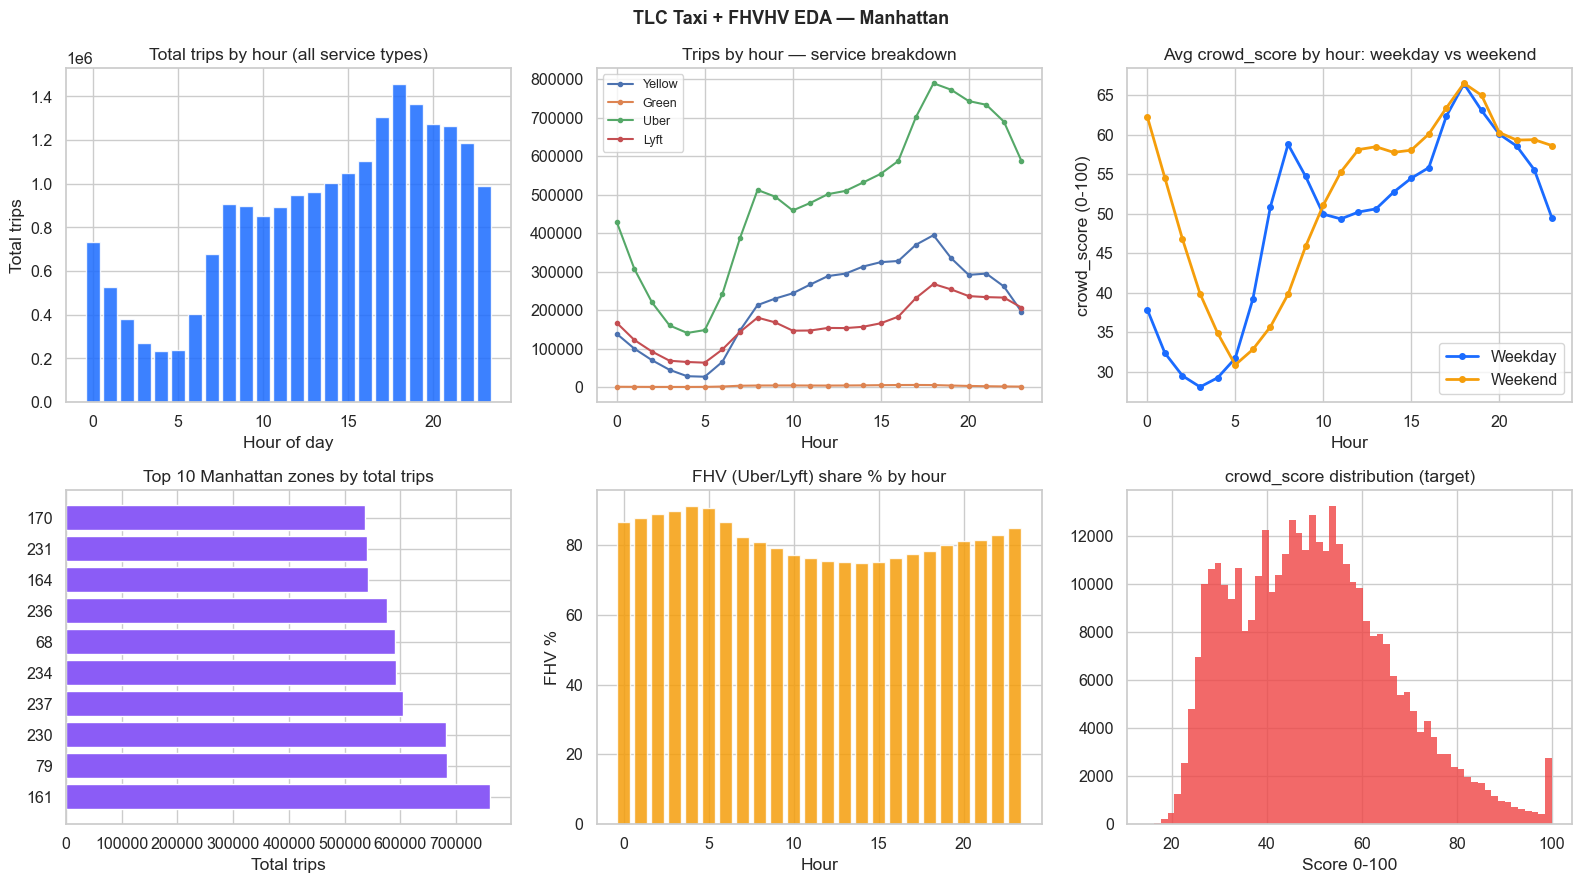

In [17]:
# Demand patterns by service type 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Total trips by hour
h_total = zone_ts.groupby('hour')['trip_count'].sum()
axes[0,0].bar(h_total.index, h_total.values, color=BLUE, alpha=0.85)
axes[0,0].set_title('Total trips by hour (all service types)')
axes[0,0].set_xlabel('Hour of day'); axes[0,0].set_ylabel('Total trips')

# Service type breakdown
svc = {
    'Yellow': zone_ts.groupby('hour')['yellow_trips'].sum(),
    'Green':  zone_ts.groupby('hour')['green_trips'].sum(),
    'Uber':   zone_ts.groupby('hour')['uber_trips'].sum(),
    'Lyft':   zone_ts.groupby('hour')['lyft_trips'].sum(),
}
for label, s in svc.items():
    axes[0,1].plot(s.index, s.values, marker='o', ms=3, lw=1.5, label=label)
axes[0,1].set_title('Trips by hour — service breakdown')
axes[0,1].set_xlabel('Hour'); axes[0,1].legend(fontsize=9)

# Weekday vs weekend crowd score
for is_wknd, label, color in [(0,'Weekday',BLUE),(1,'Weekend',ORANGE)]:
    d = zone_ts[zone_ts.is_weekend==is_wknd].groupby('hour')['crowd_score'].mean()
    axes[0,2].plot(d.index, d.values, label=label, color=color, lw=2, marker='o', ms=4)
axes[0,2].set_title('Avg crowd_score by hour: weekday vs weekend')
axes[0,2].set_xlabel('Hour'); axes[0,2].set_ylabel('crowd_score (0-100)')
axes[0,2].legend()

# Top 10 busiest Manhattan zones
top_zones = zone_ts.groupby('zone_id')['trip_count'].sum().nlargest(10)
axes[1,0].barh([str(z) for z in top_zones.index], top_zones.values, color=PURPLE)
axes[1,0].set_title('Top 10 Manhattan zones by total trips')
axes[1,0].set_xlabel('Total trips')

# FHV share by hour
zone_ts['fhv_pct_calc'] = zone_ts['fhv_trip_count'] / (zone_ts['trip_count'] + 0.01)
fhv_hr = zone_ts.groupby('hour')['fhv_pct_calc'].mean() * 100
axes[1,1].bar(fhv_hr.index, fhv_hr.values, color=ORANGE, alpha=0.85)
axes[1,1].set_title('FHV (Uber/Lyft) share % by hour')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('FHV %')

# crowd_score distribution
axes[1,2].hist(zone_ts['crowd_score'].dropna(), bins=60, color=RED, alpha=0.8, edgecolor='none')
axes[1,2].set_title('crowd_score distribution (target)')
axes[1,2].set_xlabel('Score 0-100')

plt.suptitle('TLC Taxi + FHVHV EDA — Manhattan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


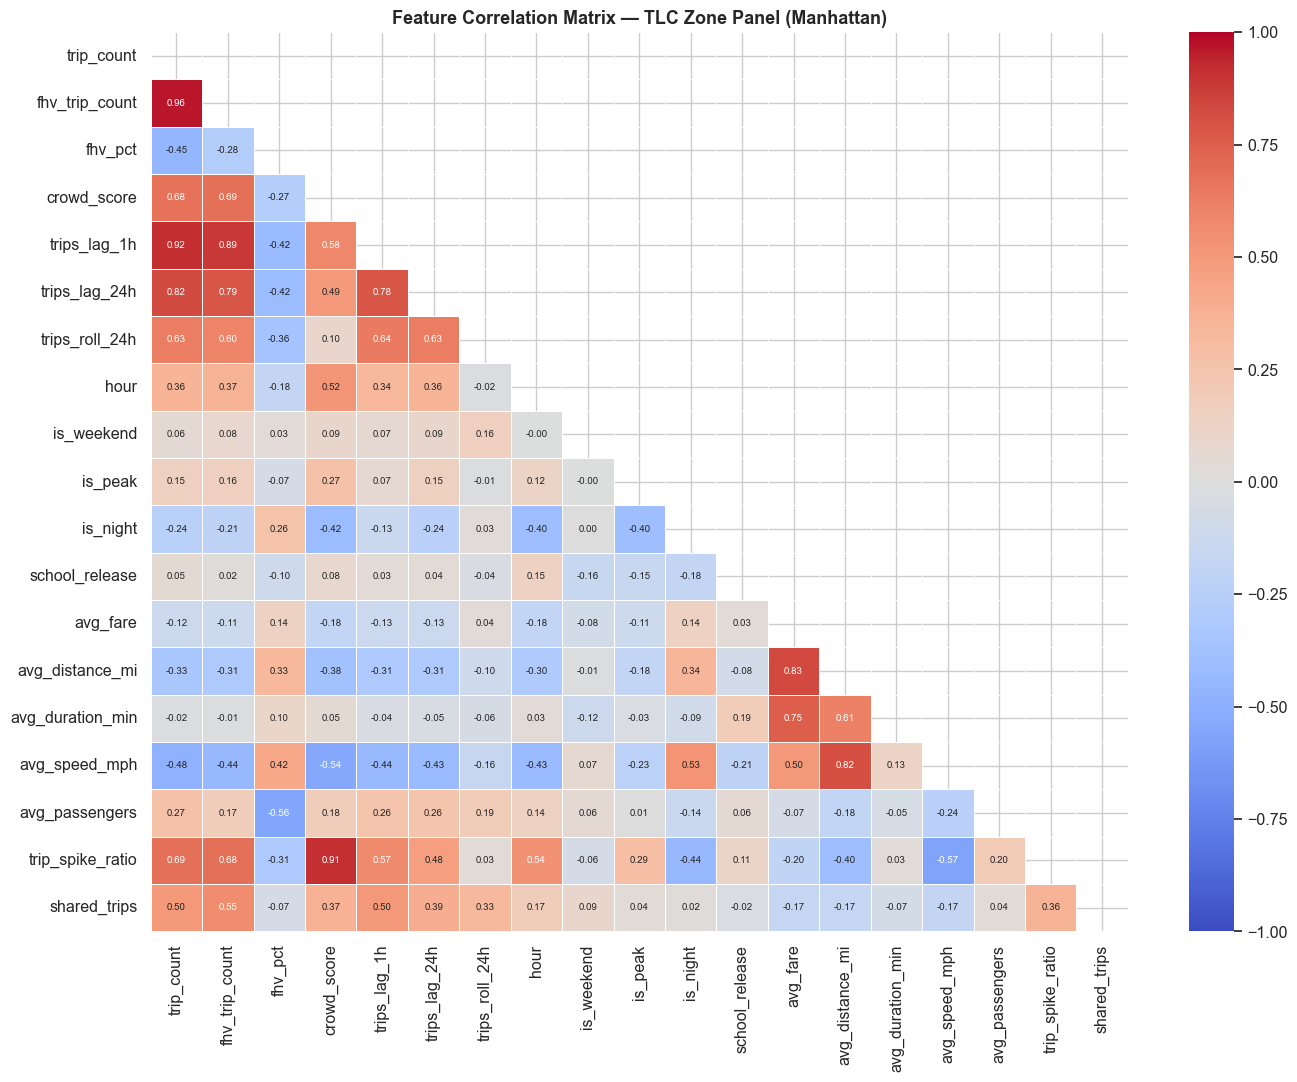

In [18]:
# Correlation matrix 
feat_cols = [
    'trip_count','fhv_trip_count','fhv_pct','crowd_score',
    'trips_lag_1h','trips_lag_24h','trips_roll_24h',
    'hour','is_weekend','is_peak','is_night','school_release',
    'avg_fare','avg_distance_mi','avg_duration_min','avg_speed_mph',
    'avg_passengers','trip_spike_ratio','shared_trips',
]

feat_cols = [c for c in feat_cols if c in zone_ts.columns]
corr = zone_ts[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix — TLC Zone Panel (Manhattan)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# DQR

In [19]:
# DQR — post-cleaning, post-feature-engineering 
dqp_clean = dqp(zone_ts)

print(f'Rows: {zone_ts.shape[0]:>10,}')
print(f'Columns: {zone_ts.shape[1]:>10,}')
print(f'Zones: {zone_ts.zone_id.nunique():>10,}')
print(f'Date range: {str(zone_ts.dt_15min.min())[:16]} → {str(zone_ts.dt_15min.max())[:16]}')


hi_null = dqp_clean[dqp_clean['null_pct'] > 5]['null_pct'].sort_values(ascending=False)
print('HIGH NULL COLUMNS (>5%): ')
if len(hi_null) == 0:
    print(' None — all columns ≥95% complete')
else:
    for col, pct in hi_null.items():
        line = f'{col:<34} {pct:>6.2f}% null'
        print(f'{line:<70}')

print('RANGE ANOMALIES:' )
checks = [
    ('trip_count', 0, 1000, 'trips per 15-min per zone'),
    ('fhv_trip_count', 0, 1000, 'FHV trips per 15-min per zone'),
    ('avg_fare', 0, 300, 'avg fare $'),
    ('avg_distance_mi', 0, 50, 'avg trip distance miles'),
    ('avg_speed_mph', 0, 55, 'avg speed mph'),
    ('crowd_score', 0, 100, 'crowd score target'),
]
for col, lo, hi, desc in checks:
    if col not in zone_ts.columns: continue
    s = zone_ts[col].dropna()
    n_viol = ((s < lo) | (s > hi)).sum()
    line = f' {col:<32} [{lo}, {hi}]  violations: {n_viol:,}'
    print(f'{line:<70}')

cs = zone_ts['crowd_score'].dropna()
print('TARGET (crowd_score):')
for stat, val in [('mean',cs.mean()),('median',cs.median()),('std',cs.std()),('skew',cs.skew())]:
    line = f'  {stat:<10} {val:>8.3f}'
    print(f' {line:<70}')


Rows:    367,250
Columns:         47
Zones:         67
Date range: 2024-01-01 00:00 → 2024-02-29 23:45
HIGH NULL COLUMNS (>5%): 
trips_lag_1wk                       12.08% null                       
RANGE ANOMALIES:
 trip_count                       [0, 1000]  violations: 0            
 fhv_trip_count                   [0, 1000]  violations: 0            
 avg_fare                         [0, 300]  violations: 1             
 avg_distance_mi                  [0, 50]  violations: 5              
 avg_speed_mph                    [0, 55]  violations: 1              
 crowd_score                      [0, 100]  violations: 0             
TARGET (crowd_score):
   mean         49.933                                                 
   median       48.830                                                 
   std          16.416                                                 
   skew          0.535                                                 


# Export 

In [20]:
# Final feature selection 
LAG_COLS = ['trips_lag_1h','trips_lag_3h','trips_lag_24h','trips_lag_1wk',
            'trips_roll_3h','trips_roll_24h','trips_roll_7d','trips_std_24h',
            'trip_spike_ratio','fhv_lag_1h','fhv_roll_24h']

for col in LAG_COLS:
    if col in zone_ts.columns:
        zone_medians = zone_ts.groupby('zone_id')[col].transform('median')
        zone_ts[col] = zone_ts[col].fillna(zone_medians)

for col in zone_ts.select_dtypes('number').columns:
    if zone_ts[col].isna().any():
        zone_ts[col] = zone_ts[col].fillna(zone_ts[col].median())

assert zone_ts.isnull().sum().sum() == 0, 'NAs remain'
print('Zero NAs remaining.')

INDEX_COLS   = ['zone_id', 'dt_15min']
TIME_FEATS   = ['hour','minute_bin','dayofweek','weekofyear','month',
                'is_weekend','is_peak','is_peak_am','is_peak_pm',
                'is_night','school_release','hour_sin','hour_cos','dow_sin','dow_cos']
DEMAND_FEATS = ['trip_count','fhv_trip_count','yellow_trips','green_trips',
                'uber_trips','lyft_trips','shared_trips','fhv_pct',
                'total_passengers','avg_passengers','avg_distance_mi','avg_fare',
                'avg_duration_min','avg_fare_per_mile','avg_speed_mph',
                'avg_tip_rate','cash_trip_pct']
LAG_FEATS    = LAG_COLS
TARGET       = ['crowd_score']

ALL_COLS = INDEX_COLS + TIME_FEATS + DEMAND_FEATS + LAG_FEATS + TARGET
ALL_COLS = [c for c in ALL_COLS if c in zone_ts.columns]

ml = zone_ts[ALL_COLS].copy()
print(f'ML-ready shape: {ml.shape[0]:,} rows × {ml.shape[1]} cols')

Zero NAs remaining.
ML-ready shape: 367,250 rows × 46 cols


In [21]:
# Chronological train/val/test split 
ml = ml.sort_values('dt_15min').reset_index(drop=True)
n = len(ml)
train = ml.iloc[:int(n*0.70)]
val   = ml.iloc[int(n*0.70):int(n*0.85)]
test  = ml.iloc[int(n*0.85):]

print(f'Train: {len(train):,} rows {train.dt_15min.min()} - {train.dt_15min.max()}')
print(f'Val: {len(val):,} rows {val.dt_15min.min()} - {val.dt_15min.max()}')
print(f'Test: {len(test):,} rows {test.dt_15min.min()} - {test.dt_15min.max()}')

ml.to_parquet(PROC / 'tlc_ml_ready.parquet', index=False)
train.to_parquet(PROC / 'tlc_train.parquet', index=False)
val.to_parquet(PROC / 'tlc_val.parquet', index=False)
test.to_parquet(PROC / 'tlc_test.parquet', index=False)
print('\nSaved! ../data/tlc/processed/')

Train: 257,074 rows 2024-01-01 00:00:00 - 2024-02-12 00:15:00
Val: 55,088 rows 2024-02-12 00:15:00 - 2024-02-21 00:00:00
Test: 55,088 rows 2024-02-21 00:00:00 - 2024-02-29 23:45:00

Saved! ../data/tlc/processed/


In [22]:
print('Final Dataset')
print(ml.dtypes.to_string())
print()
ml.head(5)

Final Dataset
zone_id                       int32
dt_15min             datetime64[us]
hour                          int32
minute_bin                    int32
dayofweek                     int32
weekofyear                    int64
month                         int32
is_weekend                    int64
is_peak                       int64
is_peak_am                    int64
is_peak_pm                    int64
is_night                      int64
school_release                int64
hour_sin                    float64
hour_cos                    float64
dow_sin                     float64
dow_cos                     float64
trip_count                    int64
fhv_trip_count                int64
yellow_trips                  int64
green_trips                   int64
uber_trips                    int64
lyft_trips                    int64
shared_trips                  int64
fhv_pct                     float64
total_passengers            float64
avg_passengers              float64
avg_distance_m

,zone_id,dt_15min,hour,minute_bin,dayofweek,weekofyear,month,is_weekend,is_peak,is_peak_am,is_peak_pm,is_night,school_release,hour_sin,hour_cos,dow_sin,dow_cos,trip_count,fhv_trip_count,yellow_trips,...,avg_passengers,avg_distance_mi,avg_fare,avg_duration_min,avg_fare_per_mile,avg_speed_mph,avg_tip_rate,cash_trip_pct,trips_lag_1h,trips_lag_3h,trips_lag_24h,trips_lag_1wk,trips_roll_3h,trips_roll_24h,trips_roll_7d,trips_std_24h,trip_spike_ratio,fhv_lag_1h,fhv_roll_24h,crowd_score
0,4,2024-01-01,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,51,48,3,...,1.020,3.889,21.141,17.141,7.019,12.681,0.054,0.000,20.000,20.000,20.000,20.000,20.417,20.854,24.448,0.000,0.897,20.000,19.938,79.440
1,211,2024-01-01,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,60,56,4,...,1.017,3.993,22.540,20.461,8.377,10.457,0.057,0.017,43.000,43.000,43.000,43.000,43.083,43.943,49.172,0.000,0.958,36.000,37.156,56.010
2,75,2024-01-01,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,77,69,7,...,1.027,4.910,20.117,15.297,6.492,16.174,0.056,0.039,58.000,58.000,58.000,57.000,59.500,55.750,55.594,0.000,1.043,48.000,46.365,62.790
3,224,2024-01-01,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,21,18,3,...,1.048,3.549,17.082,14.952,6.208,12.656,0.055,0.048,15.000,15.000,15.000,15.000,15.917,15.818,17.479,0.000,0.887,14.000,14.562,56.550
4,229,2024-01-01,0,0,0,1,1,0,0,0,0,1,0,0.000,1.000,0.000,1.000,84,66,18,...,1.071,3.873,21.731,16.211,8.108,13.208,0.068,0.131,62.000,62.000,62.000,62.000,64.417,62.135,61.679,0.000,1.036,40.000,41.281,61.490
